In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import src.formatacao as fmt

sns.set_style('whitegrid')

---
## *Pré análise*

In [2]:
df_vendas = pd.read_parquet("../processed/df_Vendas.parquet")

In [3]:
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 1145961 entries, 0 to 1145960
Data columns (total 20 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   Data Venda          1145961 non-null  datetime64[us]
 1   Id Loja             1145961 non-null  int64         
 2   Id Produto          1145961 non-null  int64         
 3   Id Cliente          1145961 non-null  int64         
 4   Qtd. Vendida        1145961 non-null  int64         
 5   Qtd. Devolvida      1145961 non-null  int64         
 6   Preço Unitário      1145961 non-null  float64       
 7   Nome Completo       1145961 non-null  str           
 8   Gênero              1145961 non-null  str           
 9   Data de Nascimento  1145961 non-null  datetime64[us]
 10  Nome Cliente        1145961 non-null  str           
 11  Localidade          1145961 non-null  str           
 12  Cidade              1145961 non-null  str           
 13  Tipo Loja           114

In [4]:
df_vendas["Id Cliente"].nunique()

18484

In [5]:
df_vendas["Id Produto"].nunique()

591

In [6]:
df_vendas["Id Loja"].nunique()

517

In [7]:
df_vendas["Data Venda"].min()

Timestamp('2022-01-01 00:00:00')

In [8]:
df_vendas["Data Venda"].max()

Timestamp('2024-12-30 00:00:00')

In [9]:
df_vendas = df_vendas.drop(columns={
    "Id Cliente",
    "Id Loja",
    "Id Produto"}
)

In [10]:
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 1145961 entries, 0 to 1145960
Data columns (total 17 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   Data Venda          1145961 non-null  datetime64[us]
 1   Qtd. Vendida        1145961 non-null  int64         
 2   Qtd. Devolvida      1145961 non-null  int64         
 3   Preço Unitário      1145961 non-null  float64       
 4   Nome Completo       1145961 non-null  str           
 5   Gênero              1145961 non-null  str           
 6   Data de Nascimento  1145961 non-null  datetime64[us]
 7   Nome Cliente        1145961 non-null  str           
 8   Localidade          1145961 non-null  str           
 9   Cidade              1145961 non-null  str           
 10  Tipo Loja           1145961 non-null  str           
 11  Nome Gerente        1145961 non-null  str           
 12  Sobrenome Gerente   1145961 non-null  str           
 13  Nome Produto        114

In [11]:
df_vendas["Ano Venda"] = df_vendas["Data Venda"].dt.year
df_vendas["Mes Venda"] = df_vendas["Data Venda"].dt.month
df_vendas["Dia Semana Venda"] = df_vendas["Data Venda"].dt.day_name()

In [12]:
df_vendas["Receita"]=(
    (df_vendas["Qtd. Vendida"]-
     df_vendas["Qtd. Devolvida"])*
    (df_vendas["Preço Unitário"]-
     df_vendas["Custo Unitário"])
)

In [13]:
df_vendas["Receita"].sum()

np.float64(317054377.21999997)

In [14]:
df_vendas["Continente"] = (
        df_vendas["Localidade"]
        .str.split(" - ", expand=True)
        .apply(lambda x: f"{x[1]}", axis=1)
    )
df_vendas["País"] = (
        df_vendas["Localidade"]
        .str.split(" - ", expand=True)
        .apply(lambda x: f"{x[0]}", axis=1)
    )

---
# **Receita por Ano**

In [15]:
receita_ano = df_vendas.groupby("Ano Venda")["Receita"].sum()
receita_ano


Ano Venda
2022    3.934781e+07
2023    1.420575e+08
2024    1.356491e+08
Name: Receita, dtype: float64

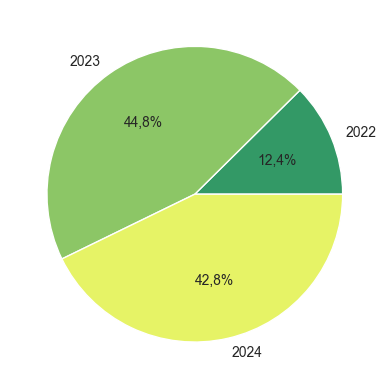

In [16]:
anos = [2022, 2023, 2024]

colors = plt.get_cmap('summer')(np.linspace(0.2, 0.9, len(anos)))
plt.pie(x=receita_ano.array, labels=anos,autopct=lambda x: f"{x:.1f}%".replace(".",","), colors=colors)

plt.savefig('../images/distReceitaAno.png', bbox_inches='tight', dpi=300)

plt.show()

---
# **Receita por Mês (sazonalidade)**

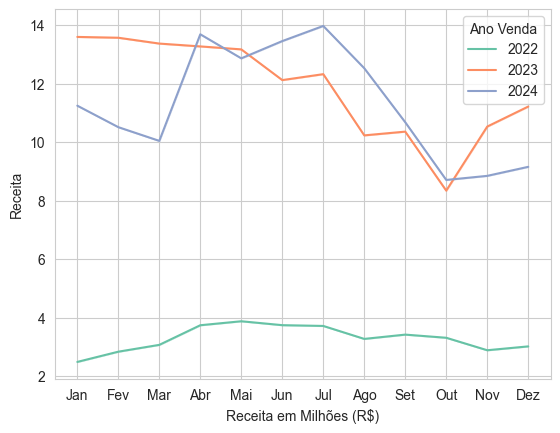

In [17]:
sns.lineplot(
    data=df_vendas, 
    x= "Mes Venda", 
    y="Receita", 
    hue="Ano Venda",
    estimator="sum", 
    palette="Set2",
    errorbar='sd'
    )
ax = plt.gca()
ax.set_xticks([1,2,3,4,5,6,7,8,9,10,11,12])
ax.set_xticklabels(["Jan", "Fev", "Mar","Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"])
ax.yaxis.set_major_formatter(FuncFormatter(fmt.moeda_milhao))

plt.xlabel('Mês')
plt.xlabel('Receita em Milhões (R$)')

plt.savefig('../images/distReceitaMes.png', bbox_inches='tight', dpi=300)

---
# **Produtos mais vendidos**

In [18]:
df_vendas["Qtd. Vendida"].sum()

np.int64(2117268)

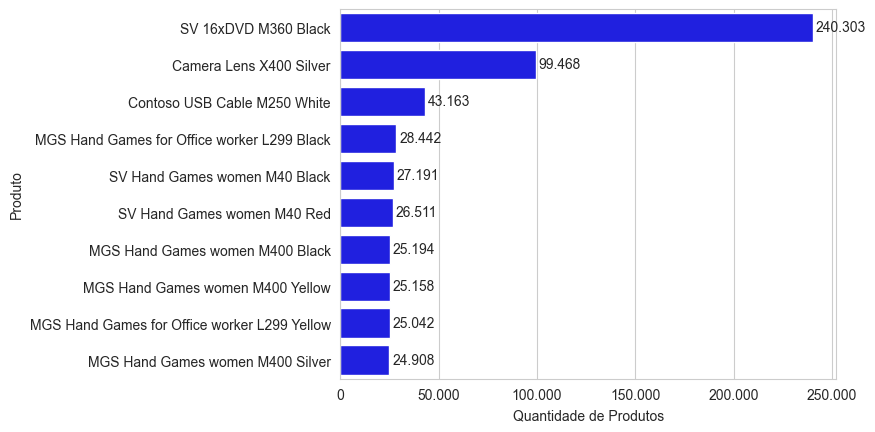

In [ ]:
quantidade_produtos = df_vendas.groupby("Nome Produto", as_index=False)["Qtd. Vendida"].sum()
top10_quantidade = quantidade_produtos.nlargest(10,"Qtd. Vendida")

ax = sns.barplot(
    data=top10_quantidade,
    x="Qtd. Vendida",
    y="Nome Produto",
    estimator="sum",
    color='b'
)

labels = [
    f"{v.get_width():,.0f}"
    .replace(",", "X")
    .replace(".", ",")
    .replace("X", ".")
    for v in ax.containers[0]
]


ax.bar_label(ax.containers[0], labels=labels, padding= 2)
ax.xaxis.set_major_formatter(FuncFormatter(fmt.quantia))
ax.set_xlabel("Quantidade de Produtos")
ax.set_ylabel("Produto")

plt.savefig('../images/qtdProdutos+Vendidos.png', bbox_inches='tight', dpi=300)

---
# **Produtos com Maior Receita**

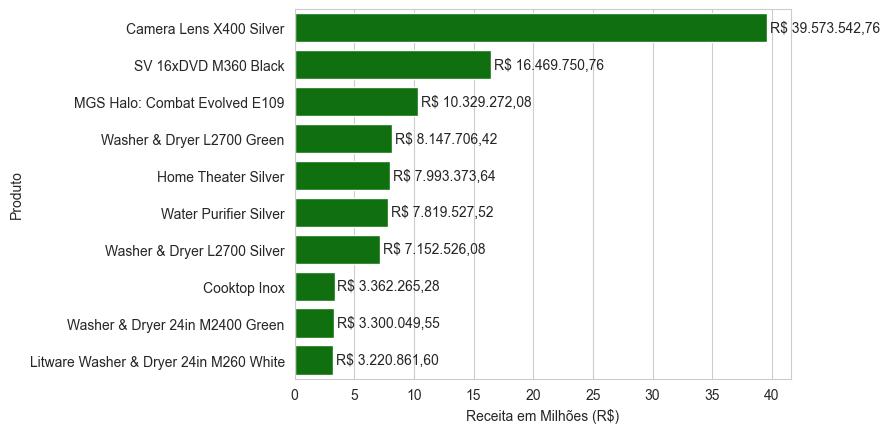

In [ ]:
receita_produtos = df_vendas.groupby("Nome Produto", as_index=False)["Receita"].sum()
top10_receita = receita_produtos.nlargest(10,"Receita")

ax = sns.barplot(
    data=top10_receita,
    x="Receita",
    y="Nome Produto",
    estimator="sum",
    color='g'
)

labels = [
    f"R$ {v.get_width():,.2f}"
    .replace(",", "X")
    .replace(".", ",")
    .replace("X", ".")
    for v in ax.containers[0]
]


ax.bar_label(ax.containers[0], labels=labels, padding= 2)
ax.xaxis.set_major_formatter(FuncFormatter(fmt.moeda_milhao))
ax.set_xlabel("Receita em Milhões (R$)")
ax.set_ylabel("Produto")
plt.savefig('../images/produtos+Receita.png', bbox_inches='tight', dpi=300)

---
## **Interseção Quantidade $\cap$ Receita**

In [21]:
intersecao = top10_quantidade.merge(
    top10_receita,
    on="Nome Produto",
    how="inner"
)
print(intersecao)

              Nome Produto  Qtd. Vendida      Receita
0     SV 16xDVD M360 Black        240303  16469750.76
1  Camera Lens X400 Silver         99468  39573542.76


Os Dois Produtos mais vendidos são, também, os dois produtos com maior receita

---
# **Clientes**

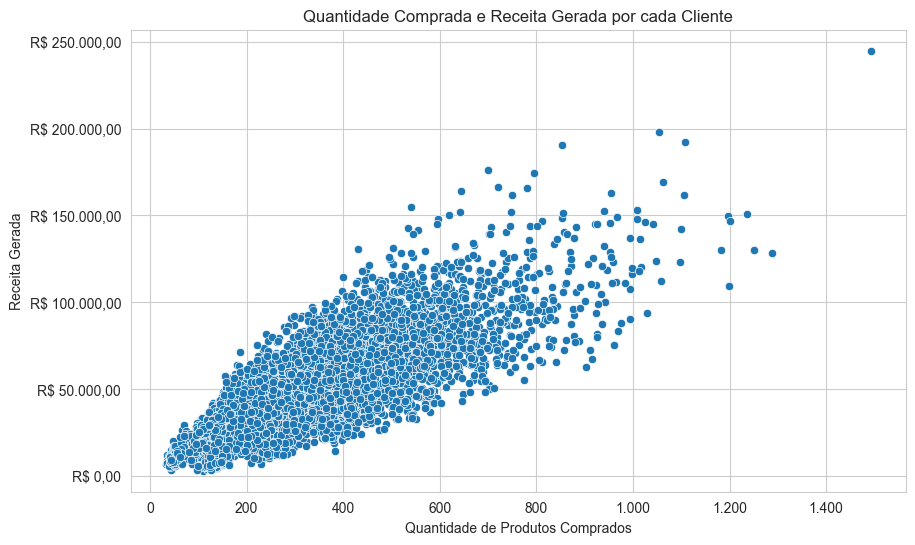

In [22]:
clientes = (
    df_vendas
    .groupby("Nome Cliente", as_index=False)
    .agg(
        Quantidade=("Qtd. Vendida", "sum"),
        Receita=("Receita", "sum")
    )
)
plt.figure(figsize=(10, 6))

scatter = sns.scatterplot(
        data=clientes,
        x="Quantidade",
        y="Receita",
    )


scatter.xaxis.set_major_formatter(FuncFormatter(fmt.quantia))
scatter.yaxis.set_major_formatter(FuncFormatter(fmt.formatar_real))

plt.xlabel("Quantidade de Produtos Comprados")
plt.ylabel("Receita Gerada")
plt.title("Quantidade Comprada e Receita Gerada por cada Cliente")
plt.savefig("../images/clientes.png", bbox_inches='tight', dpi=300)
plt.show()

## **Clientes que mais geram receita**

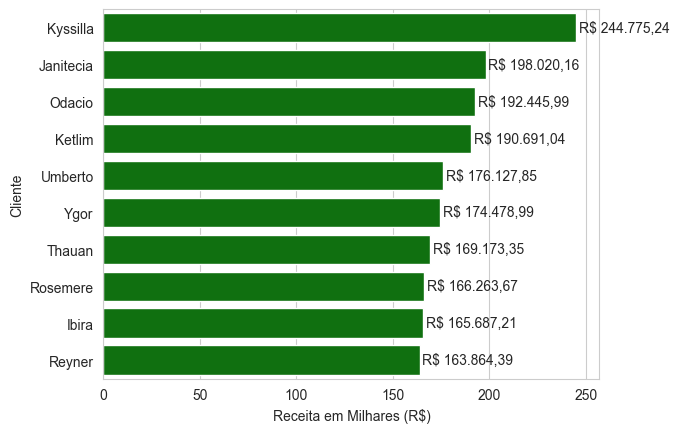

In [23]:
receita_clientes = df_vendas.groupby("Nome Cliente", as_index=False)["Receita"].sum()
top10_receita_clientes = receita_clientes.nlargest(10,"Receita")

ax = sns.barplot(
    data=top10_receita_clientes,
    x="Receita",
    y="Nome Cliente",
    estimator="sum",
    color='g'
)

labels = [
    f"R$ {v.get_width():,.2f}"
    .replace(",", "X")
    .replace(".", ",")
    .replace("X", ".")
    for v in ax.containers[0]
]


ax.bar_label(ax.containers[0], labels=labels, padding= 2)
ax.xaxis.set_major_formatter(FuncFormatter(fmt.moeda_mil))
ax.set_ylabel("Cliente")
ax.set_xlabel("Receita em Milhares (R$)")
plt.savefig('../images/clientes+Receita.png', bbox_inches='tight', dpi=300)


## **Clientes que Compram Mais Produtos**

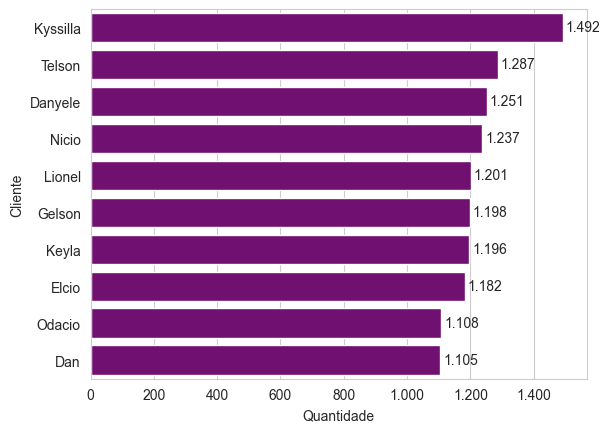

In [24]:
top10_quantidade_clientes = df_vendas.groupby("Nome Cliente", as_index=False)["Qtd. Vendida"].sum().nlargest(10,"Qtd. Vendida")
top10_quantidade_clientes

ax = sns.barplot(
    data=top10_quantidade_clientes,
    x="Qtd. Vendida",
    y="Nome Cliente",
    estimator="sum",
    color='purple'
)

labels = [
    f"{v.get_width():,.0f}"
    .replace(",",".")
    for v in ax.containers[0]
]


ax.bar_label(ax.containers[0], labels=labels, padding= 2)
ax.xaxis.set_major_formatter(FuncFormatter(fmt.quantia))
ax.set_ylabel("Cliente")
ax.set_xlabel("Quantidade")
plt.savefig('../images/clientes+Quantidade.png', bbox_inches='tight', dpi=300)

## **Interseção Clientes** 
⬆️Receita $\cap$ ⬆️Quantidade Comprada

In [25]:
intersecao_clientes = top10_receita_clientes.merge(
    top10_quantidade_clientes,
    on="Nome Cliente",
    how = "inner"
)
print(intersecao_clientes)

  Nome Cliente    Receita  Qtd. Vendida
0     Kyssilla  244775.24          1492
1       Odacio  192445.99          1108


3 dos 10 clientes que mais compram estão entre os 10 que mais geram receita

---
# **Gerentes**

In [26]:
top10_quantidade_gerente = df_vendas.groupby("Nome Gerente", as_index=False)["Qtd. Vendida"].sum().nlargest(10,"Qtd. Vendida")
top10_quantidade_gerente



,Nome Gerente,Qtd. Vendida
0,Ana,159949
12,Luiz,141810
1,Beatriz,135958
13,Marcos,135745
11,Lucas,127787
5,Gabriel,114383
15,Paulo,113137
10,Lara,111311
8,João,111123
14,Maria,110804


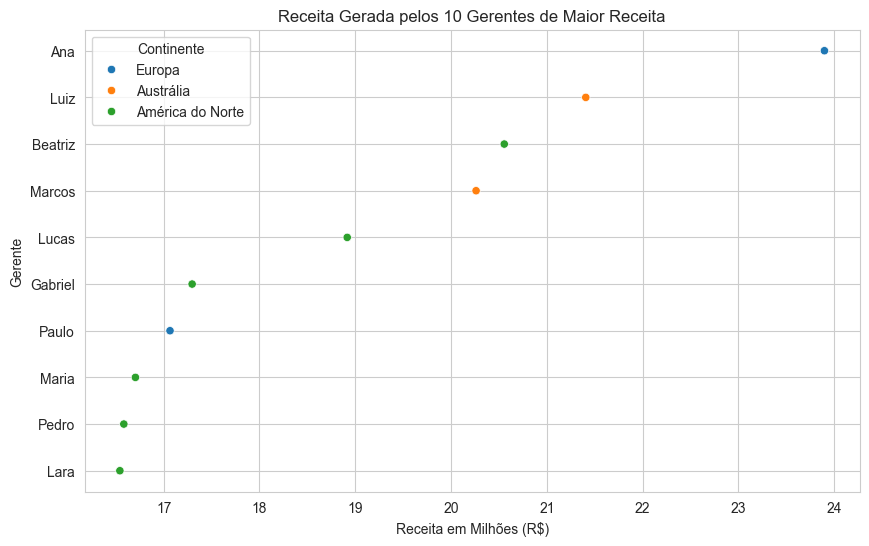

In [27]:
gerentes = (
    df_vendas
    .groupby("Nome Gerente", as_index=False)
    .agg(
        Quantidade=("Qtd. Vendida", "sum"),
        Receita=("Receita", "sum"),
        Continente=("Continente", "first")
    ).nlargest(10,"Receita")
)
plt.figure(figsize=(10, 6))

scatter = sns.scatterplot(
        data=gerentes,
        x="Receita",
        y="Nome Gerente",
        hue="Continente"
    )


scatter.xaxis.set_major_formatter(FuncFormatter(fmt.moeda_milhao))

plt.xlabel("Receita em Milhões (R$)")
plt.ylabel("Gerente")
plt.title("Receita Gerada pelos 10 Gerentes de Maior Receita")
plt.savefig("../images/gerentes.png", bbox_inches='tight', dpi=300)
plt.show()

In [28]:
top10_receita_gerente = df_vendas.groupby("Nome Gerente", as_index=False)["Receita"].sum().nlargest(10,"Receita")
top10_receita_gerente

,Nome Gerente,Receita
0,Ana,23897564.23
12,Luiz,21406219.83
1,Beatriz,20555309.02
13,Marcos,20261037.43
11,Lucas,18915849.90
5,Gabriel,17296781.28
15,Paulo,17065953.51
14,Maria,16704930.58
16,Pedro,16583824.42
10,Lara,16542625.03


In [29]:
df_vendas.loc[df_vendas["Nome Gerente"]=='João'].groupby("Nome Gerente")["Receita"].sum()

Nome Gerente
João    16533907.76
Name: Receita, dtype: float64

In [30]:
df_vendas.iloc[df_vendas["Nome Gerente"]=='Pedro'].groupby("Nome Gerente")["Qtd. Vendida"].sum()

Nome Gerente
Pedro    110377
Name: Qtd. Vendida, dtype: int64

In [31]:
intersecao_gerente = top10_quantidade_gerente.merge(
    top10_receita_gerente,
    on="Nome Gerente",
    how="inner"
)
print(intersecao_gerente)

  Nome Gerente  Qtd. Vendida      Receita
0          Ana        159949  23897564.23
1         Luiz        141810  21406219.83
2      Beatriz        135958  20555309.02
3       Marcos        135745  20261037.43
4        Lucas        127787  18915849.90
5      Gabriel        114383  17296781.28
6        Paulo        113137  17065953.51
7         Lara        111311  16542625.03
8        Maria        110804  16704930.58


---
# **Produtos Mais Devolvidos**

In [32]:
top10_quantidade_produtos_devolvidos = df_vendas.groupby("Nome Produto", as_index=False)["Qtd. Devolvida"].sum().nlargest(10,"Qtd. Devolvida")
top10_quantidade_produtos_devolvidos

,Nome Produto,Qtd. Devolvida
477,SV Hand Games women M40 Black,48
350,MGS Hand Games women M400 Silver,47
278,MGS Age of Empires III: The War Chiefs M240,46
332,MGS Hand Games for Office worker L299 Black,46
325,MGS Halo 2 for Windows Vista M220,45
275,MGS Age of Empires III: The Asian Dynasties M180,44
283,MGS Age of Mythology: Gold Edition M310,42
396,MGS Zoo Tycoon 2: Zookeeper Collection M260,42
290,MGS Bicycle Casino Games X700,41
383,MGS Shadow-run M230,41


In [33]:
df_devolucao = top10_quantidade_produtos_devolvidos.merge(
    df_vendas.groupby("Nome Produto", as_index=False)
      .agg({
          "Qtd. Vendida": "sum",
          "Preço Unitário": "first",
          "Custo Unitário": "first",
          "Receita": "sum"
      }),
    on= "Nome Produto"
)
df_devolucao["Receita Negada"] = df_devolucao["Qtd. Devolvida"] *(df_devolucao["Preço Unitário"]-df_devolucao["Custo Unitário"])
df_devolucao.nlargest(10, "Receita Negada")

,Nome Produto,Qtd. Devolvida,Qtd. Vendida,Preço Unitário,Custo Unitário,Receita,Receita Negada
8,MGS Bicycle Casino Games X700,41,4939,109.00,36.11,357015.22,2988.49
6,MGS Age of Mythology: Gold Edition M310,42,6402,79.80,36.70,274116.00,1810.20
2,MGS Age of Empires III: The War Chiefs M240,46,6231,70.13,32.25,234287.80,1742.48
4,MGS Halo 2 for Windows Vista M220,45,5437,70.13,32.25,204248.96,1704.60
5,MGS Age of Empires III: The Asian Dynasties M180,44,6434,70.13,32.25,242053.20,1666.72
7,MGS Zoo Tycoon 2: Zookeeper Collection M260,42,6823,70.13,32.25,256864.28,1590.96
9,MGS Shadow-run M230,41,5981,70.13,32.25,225007.20,1553.08
3,MGS Hand Games for Office worker L299 Black,46,28442,16.89,5.60,320590.84,519.34
0,SV Hand Games women M40 Black,48,27191,8.88,4.08,130286.40,230.40
1,MGS Hand Games women M400 Silver,47,24908,8.99,4.13,120824.46,228.42


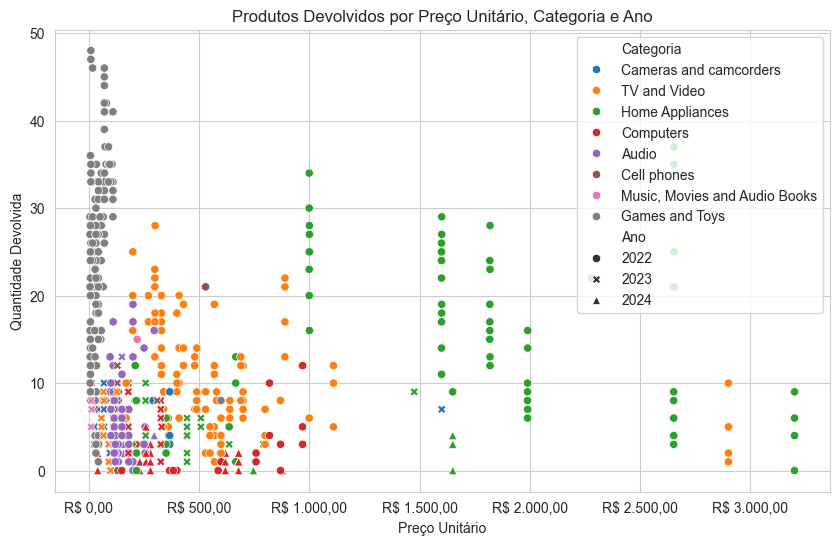

In [ ]:
produtos = (
    df_vendas
    .groupby("Nome Produto", as_index=False)
    .agg(
        Quantidade=("Qtd. Devolvida", "sum"),
        Preço=("Preço Unitário", "first"),
        Ano=("Ano Venda", "first"),
        Categoria=("Categoria", "first"),
        Marca=("Marca", "first"),
        Continente=("Continente","first")
    )   
)

plt.figure(figsize=(10, 6))



scatter = sns.scatterplot(
        data=produtos,
        x="Preço",
        y="Quantidade",
        hue="Categoria",
        style="Ano",
        markers= ["o","X","^"]
    )


scatter.xaxis.set_major_formatter(FuncFormatter(fmt.formatar_real))

plt.xlabel("Preço Unitário")
plt.ylabel("Quantidade Devolvida")
plt.title("Produtos Devolvidos por Preço Unitário, Categoria e Ano")
plt.savefig("../images/produtosDevolvidos.png", bbox_inches='tight', dpi=300)
plt.show()

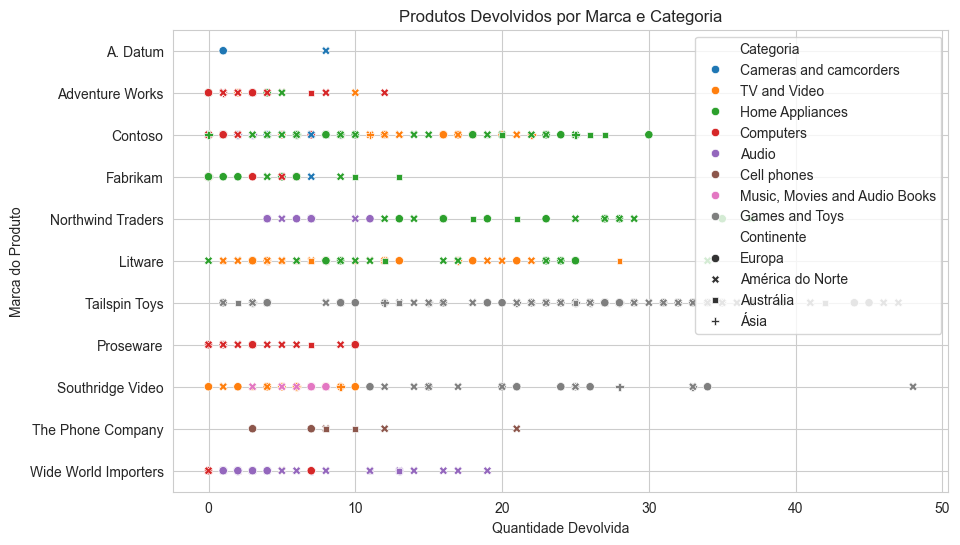

In [102]:
plt.figure(figsize=(10, 6))

marca = sns.scatterplot(
        data=produtos,
        x="Quantidade",
        y="Marca",
        hue="Categoria",
        style="Continente"
    )

plt.xlabel("Quantidade Devolvida")
plt.ylabel("Marca do Produto")
plt.title("Produtos Devolvidos por Marca e Categoria")
plt.savefig("../images/produtosDevolvidosMarca.png", bbox_inches='tight', dpi=300)
plt.show()

---
# **Localidades**

In [ ]:
df_vendas.groupby("Localidade", as_index=False)["Qtd. Vendida"].sum().nlargest(10,"Qtd. Vendida")

,Localidade,Qtd. Vendida
10,Estados Unidos - América do Norte,1153934
15,Inglaterra - Europa,181278
0,Alemanha - Europa,171759
11,França - Europa,167810
2,Austrália - Austrália,163339
4,Canada - América do Norte,85737
19,Japão - Ásia,28517
18,Itália - Europa,20712
5,China - Ásia,20554
26,Russia - Europa,12491


In [34]:
df_vendas.groupby("Localidade", as_index=False)["Receita"].sum().nlargest(10,"Receita")

,Localidade,Receita
10,Estados Unidos - América do Norte,1.734101e+08
15,Inglaterra - Europa,2.724649e+07
0,Alemanha - Europa,2.539700e+07
2,Austrália - Austrália,2.480884e+07
11,França - Europa,2.478661e+07
4,Canada - América do Norte,1.277005e+07
19,Japão - Ásia,4.307141e+06
5,China - Ásia,3.175069e+06
18,Itália - Europa,3.059420e+06
14,India - Ásia,1.848788e+06


In [35]:
df_vendas.groupby("Cidade", as_index=False)["Qtd. Vendida"].sum().nlargest(10,"Qtd. Vendida")

,Cidade,Qtd. Vendida
407,Saint Ouen,12415
129,Columbus,8379
176,Frankfurt,8320
46,Birmingham,8316
70,Burbank,8266
58,Bracknell,4508
504,Woodland Hills,4411
0,Albany,4403
104,Chatou,4393
264,Ljubljana,4391


In [36]:
df_vendas.groupby("Cidade", as_index=False)["Receita"].sum().nlargest(10,"Receita")

,Cidade,Receita
407,Saint Ouen,1832487.75
129,Columbus,1326379.40
176,Frankfurt,1283064.41
46,Birmingham,1242506.93
70,Burbank,1218777.37
58,Bracknell,741784.28
261,Litchfield County,723180.70
426,Shanghai,717906.01
364,Pasadena,713014.37
213,Holyoke,701907.72


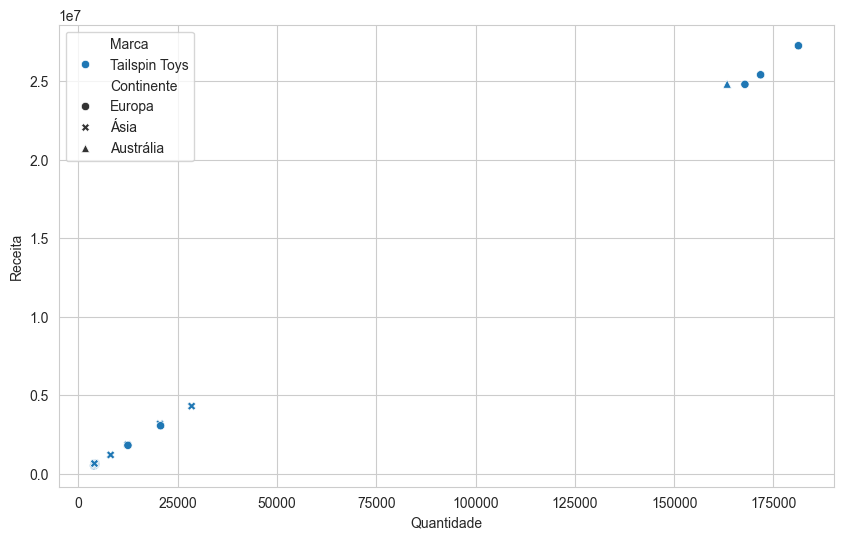

In [162]:
notAmerica = df_vendas[df_vendas["Continente"]!= "América do Norte"]

localidade = ( notAmerica
    .groupby("Localidade", as_index=False)
    .agg(
        Quantidade=("Qtd. Vendida", "sum"),
        Receita=("Receita", "sum"),
        Continente=("Continente", "first"),
        Marca=("Marca", lambda x: x.mode().iloc[0]),
        Categoria=("Categoria", lambda y: y.mode().iloc[0])
    )
)

plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
        data=localidade,
        x="Quantidade",
        y="Receita",
        style="Continente",
        hue="Marca",
        markers=["o","X","^"]
    )


# plt.xlabel("Quantidade Devolvida")
# plt.ylabel("Marca do Produto")
# plt.title("Produtos Devolvidos por Marca e Categoria")
# plt.savefig("../images/produtosDevolvidosMarca.png", bbox_inches='tight', dpi=300)
plt.show()

In [161]:
notAmerica.groupby("Categoria", as_index=False)["Receita"].sum().nlargest(10,"Receita")

,Categoria,Receita
5,Home Appliances,69824155.03
7,TV and Video,26674268.40
1,Cameras and camcorders,17525164.05
4,Games and Toys,11897758.52
3,Computers,2140580.88
0,Audio,2065577.52
2,Cell phones,520048.55
6,"Music, Movies and Audio Books",226645.13


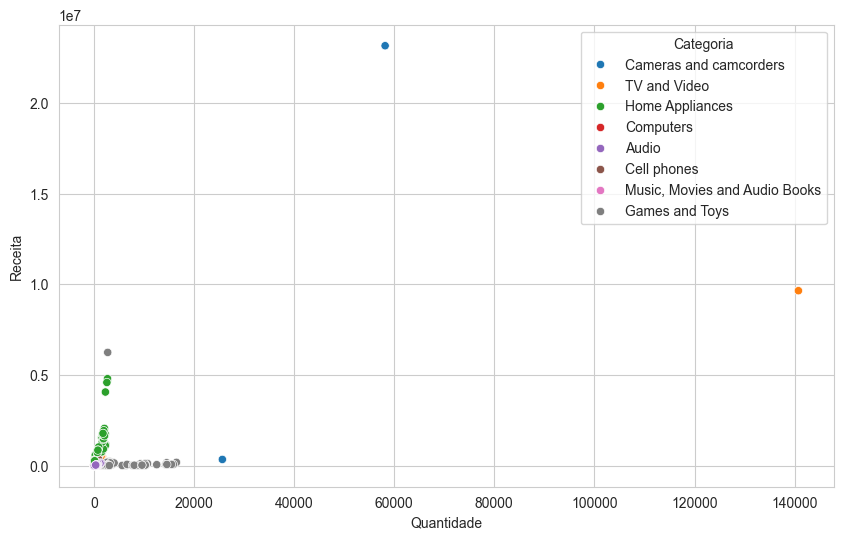

In [171]:
America = df_vendas[df_vendas["Continente"]== "América do Norte"]

localidade = (America
    .groupby("Nome Produto", as_index=False)
    .agg(
        Quantidade=("Qtd. Vendida", "sum"),
        Receita=("Receita", "sum"),
        Continente=("Continente", lambda x: x.mode().iloc[0]),
        Marca=("Marca",lambda x: x.mode().iloc[0]),
        Categoria=("Categoria",lambda x: x.mode().iloc[0])
    )
)



plt.figure(figsize=(10, 6))

ax = sns.scatterplot(
        data=localidade,
        x="Quantidade",
        y="Receita",
        hue="Categoria"
    )


# plt.xlabel("Quantidade Devolvida")
# plt.ylabel("Marca do Produto")
# plt.title("Produtos Devolvidos por Marca e Categoria")
# plt.savefig("../images/produtosDevolvidosMarca.png", bbox_inches='tight', dpi=300)
plt.show()

In [100]:
print(bar.containers[1].datavalues)

[24808839.35]


In [40]:
df_vendas.columns

Index(['Data Venda', 'Qtd. Vendida', 'Qtd. Devolvida', 'Preço Unitário',
       'Nome Completo', 'Gênero', 'Data de Nascimento', 'Nome Cliente',
       'Localidade', 'Cidade', 'Tipo Loja', 'Nome Gerente',
       'Sobrenome Gerente', 'Nome Produto', 'Categoria', 'Marca',
       'Custo Unitário', 'Ano Venda', 'Mes Venda', 'Dia Semana Venda',
       'Receita', 'Continente', 'País'],
      dtype='str')